In [13]:
import osmnx as ox
import geopandas as gpd

In [14]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

In [15]:
from src.geodata import find_possible_duplicates

In [16]:
kootenai = gpd.read_file("../data/processed/kootenai_tracts.gpkg")
kootenai.head()

,STATEFP,COUNTYFP,TRACTCE,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,16,055,001901,1400000US16055001901,16055001901,19.01,Census Tract 19.01,ID,Kootenai County,Idaho,CT,1136651855,20841605,"POLYGON ((518804.812 5256267.794, 518869.358 5..."
1,16,055,000902,1400000US16055000902,16055000902,9.02,Census Tract 9.02,ID,Kootenai County,Idaho,CT,2875540,105404,"POLYGON ((513681.538 5282909.432, 513851.67 52..."
2,16,055,001300,1400000US16055001300,16055001300,13,Census Tract 13,ID,Kootenai County,Idaho,CT,2587963,0,"POLYGON ((516034.839 5282786.303, 516035.658 5..."
3,16,055,000703,1400000US16055000703,16055000703,7.03,Census Tract 7.03,ID,Kootenai County,Idaho,CT,4486245,0,"POLYGON ((512764.547 5286117.091, 512764.091 5..."
4,16,055,000800,1400000US16055000800,16055000800,8,Census Tract 8,ID,Kootenai County,Idaho,CT,8955722,484816,"POLYGON ((511155.293 5285123.734, 511156.991 5..."


<Axes: >

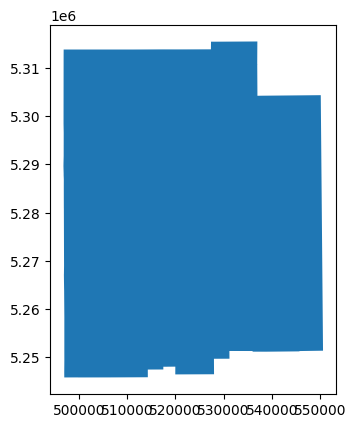

In [17]:
county_boundary = kootenai.dissolve()
county_boundary.plot()

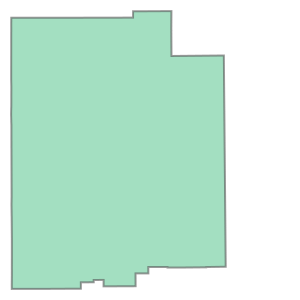

In [18]:
county_boundary.geometry.iloc[0]

In [19]:
# Find stores in county boundary
county_boundary = county_boundary.to_crs(4326)
tags = {"shop": ["supermarket", "grocery"]}
stores = ox.features_from_polygon(
    county_boundary.geometry.iloc[0],
    tags
)

In [20]:
print(stores.shape)
print(stores.columns)

(32, 46)
Index(['geometry', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:street', 'name', 'opening_hours', 'shop', 'brand',
       'brand:wikidata', 'official_name', 'addr:state', 'phone', 'website',
       'contact:facebook', 'start_date', 'building', 'designation',
       'addr:country', 'operator', 'operator:wikidata', 'payment:app:walmart',
       'payment:apple_pay', 'payment:google_pay', 'payment:samsung_pay', 'ref',
       'ref:walmart', 'sensory_friendly:accommodation',
       'sensory_friendly:conditional', 'source', 'source:name', 'layer',
       'toilets', 'branch', 'internet_access', 'organic', 'toilets:wheelchair',
       'wheelchair', 'building:levels', 'not:brand:wikidata', 'payment:cash',
       'payment:cheque', 'payment:contactless', 'payment:credit_cards',
       'payment:debit_cards', 'payment:ebt'],
      dtype='str')


In [21]:
stores[["name", "geometry", "shop", "addr:city", "addr:street"]]

name  \
element id                                         
node    6960758897                Grocery Outlet   
        8923594212            Little Town Market   
        11055182898                       Target   
        11066194802     Flour Mill Natural Foods   
        11068205595                   Albertsons   
        11075323361                C & C Grocery   
        13033494978  Lake Village Farmers Market   
        13369671009   Luxury Homes | North Idaho   
way     131635707                        Safeway   
        151791858            Walmart Supercenter   
        287413287            Walmart Supercenter   
        308996376         Lakeside Harvest Foods   
        311302083                        Safeway   
        382495858       Harrison Trading Company   
        471651382                     Fred Meyer   
        506177204         Super 1 Foods Rathdrum   
        559516111                    WinCo Foods   
        559516127                Natural Grocers   
        653295195                         Yoke's   
        683463082            Walmart Supercenter   
        886523884        Super One Foods - Athol   
        895732223         Miller's Harvest Foods   
        1020438079                   Wenig Foods   
        1095083676                 Super 1 Foods   
        1097544427         US Foods Chef's Store   
        1098123267               Super One Foods   
        1099465785              Pilgrim's Market   
        1099480159                       Safeway   
        1213069443              Gittel's Grocery   
        1213416599              Jordan's Grocery   
        1421603066                Grocery Outlet   
        1428152711                  Trader Joe's   

                                                              geometry  \
element id                                                               
node    6960758897                         POINT (-116.79343 47.70574)   
        8923594212                         POINT (-116.70236 47.94815)   
        11055182898                        POINT (-116.79152 47.73515)   
        11066194802                         POINT (-116.7877 47.75288)   
        11068205595                        POINT (-116.78903 47.74616)   
        11075323361                         POINT (-116.83054 47.7443)   
        13033494978                        POINT (-116.75181 47.67029)   
        13369671009                        POINT (-116.80389 47.69526)   
way     131635707    POLYGON ((-116.78835 47.70852, -116.7883 47.70...   
        151791858    POLYGON ((-116.90813 47.71331, -116.90614 47.7...   
        287413287    POLYGON ((-117.03103 47.70473, -117.03096 47.7...   
        308996376    POLYGON ((-116.7687 47.67407, -116.76793 47.67...   
        311302083    POLYGON ((-116.79028 47.69386, -116.79028 47.6...   
        382495858    POLYGON ((-116.78593 47.45417, -116.7856 47.45...   
        471651382    POLYGON ((-116.79365 47.71203, -116.79365 47.7...   
        506177204    POLYGON ((-116.87765 47.81589, -116.87631 47.8...   
        559516111    POLYGON ((-116.80618 47.70356, -116.80564 47.7...   
        559516127    POLYGON ((-116.79115 47.70638, -116.79115 47.7...   
        653295195    POLYGON ((-116.92555 47.71178, -116.92553 47.7...   
        683463082    POLYGON ((-116.79436 47.74842, -116.79435 47.7...   
        886523884    POLYGON ((-116.69394 47.95058, -116.69349 47.9...   
        895732223    POLYGON ((-116.86787 47.96253, -116.86786 47.9...   
        1020438079   POLYGON ((-116.99125 47.71792, -116.99125 47.7...   
        1095083676   POLYGON ((-116.9358 47.71538, -116.9359 47.715...   
        1097544427   POLYGON ((-116.78308 47.69992, -116.78349 47.6...   
        1098123267   POLYGON ((-116.79013 47.71585, -116.79075 47.7...   
        1099465785   POLYGON ((-116.77964 47.68752, -116.77985 47.6...   
        1099480159   POLYGON ((-116.78149 47.68285, -116.7821 47.68...   
        1213069443   POLYGON ((-116.78649 47.68636, -11

In [22]:
duplicate_table = find_possible_duplicates(stores)
duplicate_table.head(20)

name      addr:city  \
element id                                               
way     311302083               Safeway  Coeur d'Alene   
        1099480159              Safeway  Coeur D'Alene   
        131635707               Safeway  Coeur d'Alene   
node    6960758897       Grocery Outlet            NaN   
way     1421603066       Grocery Outlet     Post Falls   
        151791858   Walmart Supercenter     Post Falls   
        287413287   Walmart Supercenter     Post Falls   
        683463082   Walmart Supercenter         Hayden   

                                addr:street                        geometry  \
element id                                                                    
way     311302083            Ironwood Drive  POINT (515774.478 5282270.684)   
        1099480159         North 4th Street  POINT (516376.469 5281101.996)   
        131635707        West Neider Avenue  POINT (515918.442 5283954.018)   
node    6960758897                      NaN  POINT (515496.942 5283616.399)   
way     1421603066         North Highway 41  POINT (508084.904 5286507.542)   
        151791858        East Mullan Avenue  POINT (506971.509 5284494.234)   
        287413287       West Pointe Parkway  POINT (497685.352 5283413.098)   
        683463082   West Honeysuckle Avenue  POINT (515494.044 5288430.484)   

                   nearest_same_name_m  is_duplicate  
element id                                            
way     311302083          1314.619176         False  
        1099480159         1314.619176         False  
        131635707          1689.479019         False  
node    6960758897         7955.942071         False  
way     1421603066         7955.942071         False  
        151791858          9348.881129         False  
        287413287          9348.881129         False  
        683463082          9387.633389         False

In [23]:
# stores = stores[stores.geometry.type == "Point"]
# print(stores.shape)
# print(stores[["name"]])

In [24]:
# ax = county_boundary.plot(figsize=(8,8), edgecolor="black")

# stores.plot(
#     ax=ax,
#     color="red",
#     markersize=20
# )